## Building Makemore Part 2: Multilayer Perceptron (MLP) Language Model
Building Makemore Part 2: Multilayer Perceptron (MLP) Language Model

### Environment Setup & Data Loading
What this cell does: Imports PyTorch, sets deterministic random seeds across CPU and CUDA for reproducible weight initialization, reads names.txt, and builds character-to-integer mappings (stoi, itos).

In [1]:
import torch
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
%matplotlib inline

# Fix random seed for reproducibility
SEED = 2147483647
random.seed(SEED)
torch.manual_seed(SEED)

# Read names dataset
words = open('names.txt', 'r').read().splitlines()

# Build vocabulary mappings ('.' at index 0 for start/end token)
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)

print(f"Total words: {len(words)}")
print(f"Vocabulary size: {vocab_size}")

Total words: 32033
Vocabulary size: 27


### Dataset Construction & Sliding Window <br> 
Transforms raw strings into a supervised context-target dataset $(X, Y)$ using a rolling window of length block_size $k$. Initial contexts are padded with 0 (.).

In [2]:
block_size = 3 # Context length: number of characters used to predict the next

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # Slide context window left by 1
    return torch.tensor(X), torch.tensor(Y)

# Build complete dataset
X, Y = build_dataset(words)
print(f"Dataset X shape: {X.shape}")
print(f"Dataset Y shape: {Y.shape}")
print(f"First 5 context-target pairs:\n  X: {X[:5]}\n  Y: {Y[:5]}")

Dataset X shape: torch.Size([228146, 3])
Dataset Y shape: torch.Size([228146])
First 5 context-target pairs:
  X: tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]])
  Y: tensor([ 5, 13, 13,  1,  0])


### Train / Validation / Test Splitting (80 / 10 / 10)
Randomly shuffles dataset words and creates isolated splits to prevent memorization and ensure proper hyperparameter tuning.

In [3]:
# Shuffle words randomly
random.seed(SEED)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80% Training
Xdev, Ydev = build_dataset(words[n1:n2])   # 10% Validation / Dev
Xte,  Yte  = build_dataset(words[n2:])     # 10% Test

print(f"Training samples   (Xtr) : {Xtr.shape[0]}")
print(f"Validation samples (Xdev): {Xdev.shape[0]}")
print(f"Test samples       (Xte) : {Xte.shape[0]}")

Training samples   (Xtr) : 182546
Validation samples (Xdev): 22840
Test samples       (Xte) : 22760


### Parameter Initialization <br> 
Initializes all network parameters (C, W1, b1, W2, b2) as tensors with requires_grad=True.Dimensions:C: $(27 \times 10)$ — Embedding lookup table ($d=10$).W1: $(30 \times 200)$ — Input size is $k \cdot d = 3 \times 10 = 30$; hidden units $h=200$.b1: $(200,)$ — Hidden biases.W2: $(200 \times 27)$ — Output weights mapping 200 hidden units to 27 logits.b2: $(27,)$ — Output biases.

In [4]:
g = torch.Generator().manual_seed(SEED)

n_embd = 10   # Embedding dimension d
n_hidden = 200 # Hidden layer size h

C  = torch.randn((vocab_size, n_embd),          generator=g, requires_grad=True)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g, requires_grad=True)
b1 = torch.randn((n_hidden,),                   generator=g, requires_grad=True)
W2 = torch.randn((n_hidden, vocab_size),         generator=g, requires_grad=True)
b2 = torch.randn((vocab_size,),                  generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]
total_params = sum(p.nelement() for p in parameters)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 11897


### Learning Rate Exponent Sweep <br> 
Sweeps learning rates exponentially between $10^{-3}$ and $10^0$ over 1,000 steps on mini-batches to plot lre vs loss and discover the optimal step size.

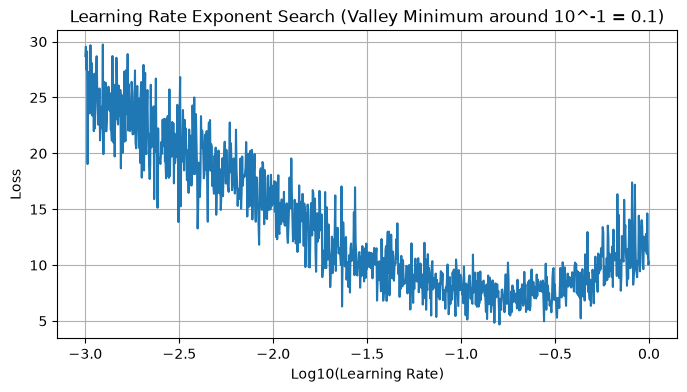

In [5]:
# Create exponential learning rate candidates: 10^(-3) to 10^0
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri, lossi = [], []

# Diagnostic loop on small random model copy
for i in range(1000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # Forward pass using .view(-1, 30) for O(1) memory flattening
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()
    
    # Step with candidate lr
    lr = lrs[i]
    for p in parameters: p.data += -lr * p.grad
    
    lri.append(lre[i].item())
    lossi.append(loss.item())

# Plot exponent vs loss to locate valley minimum
plt.figure(figsize=(8, 4))
plt.plot(lri, lossi)
plt.title("Learning Rate Exponent Search (Valley Minimum around 10^-1 = 0.1)")
plt.xlabel("Log10(Learning Rate)")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Model Training Loop with Mini-Batching & LR Decay <br> 
Trains the network using Mini-Batch SGD ($B=32$). Executes 100,000 steps at learning rate $\eta=0.1$, followed by 100,000 steps at decayed rate $\eta=0.01$.

In [7]:
# Re-initialize parameters for clean training
g = torch.Generator().manual_seed(SEED)
C  = torch.randn((vocab_size, n_embd),          generator=g, requires_grad=True)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g, requires_grad=True)
b1 = torch.randn((n_hidden,),                   generator=g, requires_grad=True)
W2 = torch.randn((n_hidden, vocab_size),         generator=g, requires_grad=True)
b2 = torch.randn((vocab_size,),                  generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

batch_size = 32
stepi, log_lossi = [], []

print("--- Starting Optimization Loop ---")
for i in range(200000):
    # 1. Sample mini-batch indices
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    
    # 2. Forward pass
    emb = C[Xtr[ix]]                                    # Shape (32, 3, 10)
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1) # Shape (32, 200)
    logits = h @ W2 + b2                                # Shape (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # 3. Zero gradients
    for p in parameters: p.grad = None
    
    # 4. Backward pass
    loss.backward()
    
    # 5. Decay learning rate at step 100k (0.1 -> 0.01)
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # Log metrics
    if i % 20000 == 0:
        print(f"Step {i:6d} / 200000 | Loss: {loss.item():.4f} | LR: {lr}")
    stepi.append(i)
    log_lossi.append(torch.log10(loss).item())

--- Starting Optimization Loop ---
Step      0 / 200000 | Loss: 26.4380 | LR: 0.1
Step  20000 / 200000 | Loss: 2.4250 | LR: 0.1
Step  40000 / 200000 | Loss: 2.3453 | LR: 0.1
Step  60000 / 200000 | Loss: 2.2974 | LR: 0.1
Step  80000 / 200000 | Loss: 2.4182 | LR: 0.1
Step 100000 / 200000 | Loss: 2.2157 | LR: 0.01
Step 120000 / 200000 | Loss: 2.3533 | LR: 0.01
Step 140000 / 200000 | Loss: 2.0627 | LR: 0.01
Step 160000 / 200000 | Loss: 2.3805 | LR: 0.01
Step 180000 / 200000 | Loss: 2.0210 | LR: 0.01


## Full Dataset Loss Evaluation (Train vs. Val Split) <br>
Evaluates loss across full Xtr and Xdev split sets without mini-batch noise to diagnose underfitting vs. overfitting.

In [8]:
@torch.no_grad()
def evaluate_split(split_x, split_y):
    emb = C[split_x]
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, split_y)
    return loss.item()

train_loss = evaluate_split(Xtr, Ytr)
val_loss   = evaluate_split(Xdev, Ydev)

print("--- Full Dataset Performance ---")
print(f"Training Loss   : {train_loss:.4f}")
print(f"Validation Loss : {val_loss:.4f}")

if abs(train_loss - val_loss) < 0.05:
    print("Diagnosis: Model is UNDERFITTING. Capacity can be expanded.")
elif train_loss < val_loss - 0.1:
    print("Diagnosis: Model is OVERFITTING. Add regularization or data.")

--- Full Dataset Performance ---
Training Loss   : 2.1207
Validation Loss : 2.1791


### Character Generation / Inference Loop
Generates 10 new synthetic names by sampling tokens iteratively from Softmax predicted probability distributions using a sliding context window.

In [10]:
g = torch.Generator().manual_seed(SEED + 10)

print("--- Synthetic Names Generated by MLP ---")
for _ in range(10):
    out = []
    context = [0] * block_size # Initialize with padded '...'
    
    while True:
        # Embed current context window
        x_inp = torch.tensor([context])
        emb = C[x_inp]
        
        # Forward pass
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        # Sample next index
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        # Slide context window left
        context = context[1:] + [ix]
        
        if ix == 0: # Reached end token '.'
            break
        out.append(itos[ix])
        
    print(''.join(out))

--- Synthetic Names Generated by MLP ---
carmahzamille
khiimleigentleenaan
keja
hutefa
livia
kaeli
nellara
chaiiv
kaleigh
ham
